# Feature engineering: создание признаков

В этом ноутбуке разберём **feature engineering** — создание и преобразование признаков для улучшения работы моделей.

**Цели ноутбука:**
- Понять, какие типы новых признаков часто помогают моделям.
- На примере синтетических данных построить полиномиальные и взаимодействующие признаки (interaction features).
- Посмотреть на бининг (дискретизацию) и обработку категориальных признаков.
- Показать простые приёмы отбора признаков (feature selection) в `sklearn`.

---

**Содержание:** Идея feature engineering → Синтетические данные → Полиномиальные и взаимодействующие признаки → Бининг чисел → Категориальные признаки → Отбор признаков → Пайплайн → Выводы.


## Идея feature engineering

Алгоритмы машинного обучения работают с **пространством признаков**. Даже простая модель (например, логистическая регрессия) может стать очень мощной, если ей подать **хорошо сконструированные признаки**:

- полиномиальные признаки (квадраты, кубы и т.п.),
- произведения признаков (interaction features),
- агрегаты (средние/суммы по группам),
- биннинги (разбиение на интервалы),
- кодирование категорий и т.д.

Часто feature engineering важнее выбора "правильного" алгоритма.

В этом ноутбуке мы сфокусируемся на простых числовых примерах с `sklearn`. Для более сложных сценариев (NLP, CV, табличные данные в продакшене) подходы шире, но принципы похожи: сделать структуру данных более "удобной" для модели.


## Синтетические данные для примеров

Сгенерируем данные так, чтобы:
- **первые два признака** имели нелинейную границу решений (круги), тогда полиномиальные признаки будут полезны;
- **остальные признаки** — случайные/шумовые, для демонстрации отбора по корреляции.


Train shape: (350, 10)
Test shape:  (150, 10)


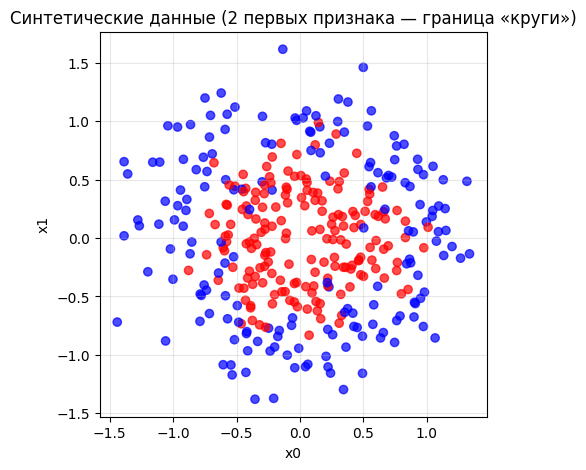

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Первые 2 признака — нелинейная граница (круги): полиномиальные признаки помогут
X_circ, y = make_circles(n_samples=500, noise=0.2, factor=0.5, random_state=42)

# Добавляем ещё 8 признаков (шум + немного корреляций) для секции отбора по корреляции
X_extra, _ = make_classification(
    n_samples=500, n_features=8, n_informative=2, n_redundant=3,
    n_repeated=0, n_clusters_per_class=1, random_state=43,
)
X = np.hstack([X_circ, X_extra])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

plt.figure(figsize=(5, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", alpha=0.7)
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Синтетические данные (2 первых признака — граница «круги»)")
plt.grid(alpha=0.3)
plt.show()

## Полиномиальные и взаимодействующие признаки

Некоторые границы решений плохо описываются линейной моделью: им нужна **нелинейность**. Один из простых способов добавить нелинейности — расширить пространство признаков полиномиальными комбинациями исходных:

- $x_0^2, x_1^2, x_0 x_1, x_0^3, x_1^3$ и т.д.

В `sklearn` это делает `PolynomialFeatures`. Ниже сравним логистическую регрессию:
- на исходных признаках,
- на полиномиально расширенных признаках.


In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Логистическая регрессия на исходных признаках
log_reg_base = LogisticRegression(max_iter=1000, random_state=42)
log_reg_base.fit(X_train_scaled[:, :2], y_train)
base_acc = accuracy_score(y_test, log_reg_base.predict(X_test_scaled[:, :2]))

# Полиномиальные признаки до степени 3 для первых двух признаков
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled[:, :2])
X_test_poly = poly.transform(X_test_scaled[:, :2])

log_reg_poly = LogisticRegression(max_iter=2000, random_state=42)
log_reg_poly.fit(X_train_poly, y_train)
poly_acc = accuracy_score(y_test, log_reg_poly.predict(X_test_poly))

print("Логистическая регрессия на исходных признаках (2D):", base_acc)
print("Логистическая регрессия с полиномиальными признаками (degree=3):", poly_acc)

print("\nЧисло признаков до:", X_train_scaled[:, :2].shape[1])
print("Число признаков после PolynomialFeatures:", X_train_poly.shape[1])

Логистическая регрессия на исходных признаках (2D): 0.5333333333333333
Логистическая регрессия с полиномиальными признаками (degree=3): 0.88

Число признаков до: 2
Число признаков после PolynomialFeatures: 9


## Взаимодействия (interaction features)

Иногда достаточно не все полиномы, а только **произведения признаков** (взаимодействия). В `PolynomialFeatures` за это отвечает параметр `interaction_only=True`.

Ниже пример формирования только взаимодействий и объединения их с исходными признаками.


In [3]:
# Только взаимодействия (x0 * x1)
poly_inter = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_train_inter = poly_inter.fit_transform(X_train_scaled[:, :2])
X_test_inter = poly_inter.transform(X_test_scaled[:, :2])

print("Признаки после interaction_only=True (degree=2):", X_train_inter.shape[1])
print("Пример строки:")
print("[x0, x1, x0*x1] =", X_train_inter[0])

Признаки после interaction_only=True (degree=2): 3
Пример строки:
[x0, x1, x0*x1] = [-0.70274069 -0.48124045  0.33818725]


## Бининг (дискретизация) числовых признаков

**Бининг** переводит непрерывный признак в категориальный по интервалам:
- удобно для моделей, которые хорошо работают с категориями или кусочно-постоянными эффектами (деревья);
- позволяет сгладить шум и выделить диапазоны значений.

В `sklearn` это делает `KBinsDiscretizer`. Покажем пример для первого признака.


In [4]:
from sklearn.preprocessing import KBinsDiscretizer

kb = KBinsDiscretizer(n_bins=4, encode="onehot-dense", strategy="quantile")

# Берём только первый признак
x0_train = X_train_scaled[:, [0]]
x0_test = X_test_scaled[:, [0]]

x0_train_binned = kb.fit_transform(x0_train)
x0_test_binned = kb.transform(x0_test)

print("Форма до биннинга:", x0_train.shape)
print("Форма после биннинга (onehot):", x0_train_binned.shape)
print("Пример строки (4 бина):", x0_train_binned[0])

Форма до биннинга: (350, 1)
Форма после биннинга (onehot): (350, 4)
Пример строки (4 бина): [0. 1. 0. 0.]


/home/kvs/miniconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


## Категориальные признаки: напоминание

Из блокнота про предобработку:
- `OneHotEncoder` превращает категориальный признак в набор 0/1 столбцов;
- `ColumnTransformer` позволяет применить разные преобразования к числовым и категориальным столбцам.

Ниже — небольшой пример с искусственным категориальным признаком ("город") и двумя числовыми признаками.


In [5]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from IPython.display import display
import pandas as pd

np.random.seed(42)
n = 10
X_num = np.random.randn(n, 2)
city = np.random.choice(["A", "B", "C"], size=n)
X_cat = city.reshape(-1, 1)

X_table = np.hstack([X_num, X_cat.astype(object)])

ct = ColumnTransformer(
    [("num", "passthrough", [0, 1]), ("cat", OneHotEncoder(sparse_output=False), [2])],
    remainder="drop",
)

X_encoded = ct.fit_transform(X_table)

cols_before = ["num_0", "num_1", "city"]
df_before = pd.DataFrame(X_table, columns=cols_before)
cols_after = ["num_0", "num_1", "city_A", "city_B", "city_C"]
df_after = pd.DataFrame(X_encoded, columns=cols_after)

print("До кодирования:")
display(df_before.head())

print("После OneHot-кодирования:")
display(df_after.head())

До кодирования:


,num_0,num_1,city
0,0.496714,-0.138264,B
1,0.647689,1.52303,B
2,-0.234153,-0.234137,C
3,1.579213,0.767435,B
4,-0.469474,0.54256,C


После OneHot-кодирования:


,num_0,num_1,city_A,city_B,city_C
0,0.496714,-0.138264,0.0,1.0,0.0
1,0.647689,1.52303,0.0,1.0,0.0
2,-0.234153,-0.234137,0.0,0.0,1.0
3,1.579213,0.767435,0.0,1.0,0.0
4,-0.469474,0.54256,0.0,0.0,1.0


## Отбор признаков (feature selection)

Когда признаков много, часть из них может быть:
- шумовой,
- сильно коррелированной,
- слабо связанной с целевой переменной.

Простые подходы к отбору признаков в `sklearn`:
- `SelectKBest` с критерием `f_classif` (ANOVA) или `mutual_info_classif`;
- `SelectFromModel` на основе важностей модели (например, случайного леса или логистической регрессии с L1).

Ниже пример `SelectKBest` с `f_classif` на нашем синтетическом датасете.


## Корреляции между признаками и фильтр по порогу

Иногда среди признаков есть пары с очень высокой линейной связью (|corr| ≈ 1). Такие признаки часто **избыточны**:
- для интерпретируемых линейных моделей это даёт мультиколлинеарность и нестабильные веса,
- в общем случае можно просто удалить один из сильно коррелирующих признаков.

Обычно делают так:
1. Строят матрицу корреляций по train.
2. Задают порог (например, 0.9).
3. Для каждой пары с |corr| > порога удаляют один признак.

Ниже — пример такого фильтра для синтетических `X_train_scaled`.

Матрица |corr| между признаками (исходный датасет с redundant-фичами):


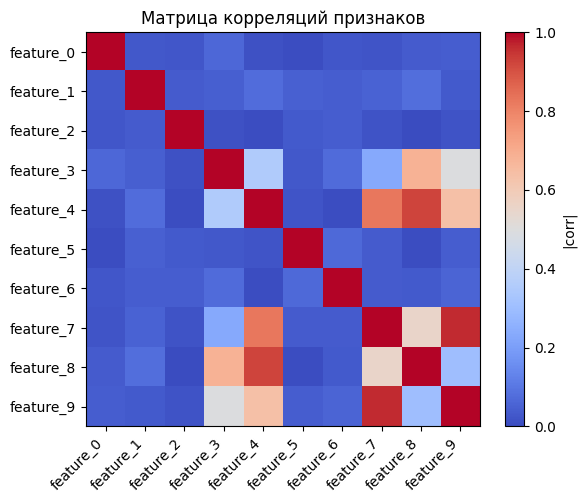


Признаки, помеченные к удалению (|corr| > 0.9): ['feature_8', 'feature_9']
Оригинальное число признаков: 10
Число признаков после фильтра по корреляции: 8


In [6]:
import pandas as pd

# Матрица корреляций для исходных масштабированных признаков
cols = [f"feature_{i}" for i in range(X_train_scaled.shape[1])]
df_train = pd.DataFrame(X_train_scaled, columns=cols)

corr = df_train.corr().abs()
print("Матрица |corr| между признаками (исходный датасет с redundant-фичами):")

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", vmin=0.0, vmax=1.0)
plt.colorbar(label="|corr|")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Матрица корреляций признаков")
plt.tight_layout()
plt.show()

# Простой фильтр: удаляем один из признаков в каждой паре с |corr| > 0.9
threshold = 0.9
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
print("\nПризнаки, помеченные к удалению (|corr| > 0.9):", to_drop)

X_train_filtered = df_train.drop(columns=to_drop).values

X_test_df = pd.DataFrame(X_test_scaled, columns=cols)
X_test_filtered = X_test_df.drop(columns=to_drop).values

print("Оригинальное число признаков:", X_train_scaled.shape[1])
print("Число признаков после фильтра по корреляции:", X_train_filtered.shape[1])

## Влияние удаления сильно коррелирующих признаков на качество модели

Высокая корреляция признаков в первую очередь делает веса **линейных** моделей нестабильными (мультиколлинеарность). Для сравнения «полный набор vs после фильтра» здесь используется **случайный лес** — он умеет строить нелинейные границы (у нас первые два признака — «круги») и даёт осмысленную точность; с логистической регрессией на этих данных точность была бы около 0.5.

Сравниваем:
- случайный лес на полном наборе признаков,
- тот же лес на наборе после удаления сильно коррелирующих признаков.

Ожидание: фильтрация не ухудшает качество (часто слегка улучшает или не меняет), при этом модель проще и веса/важности признаков стабильнее.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Случайный лес на полном наборе признаков
X_train_full = X_train_scaled
X_test_full = X_test_scaled

clf_full = RandomForestClassifier(n_estimators=100, random_state=42)
clf_full.fit(X_train_full, y_train)
acc_full = accuracy_score(y_test, clf_full.predict(X_test_full))

# Тот же лес на наборе после фильтра по корреляции
clf_filt = RandomForestClassifier(n_estimators=100, random_state=42)
clf_filt.fit(X_train_filtered, y_train)
acc_filt = accuracy_score(y_test, clf_filt.predict(X_test_filtered))

print("Точность случайного леса:")
print("  Полный набор признаков:", acc_full)
print("  После удаления сильно коррелирующих признаков:", acc_filt)

print("\nИнтерпретация:")
print("- если acc_filt >= acc_full, фильтрация не ухудшила качество (часто слегка улучшает или не меняет);\n"
      "- меньше признаков — проще модель и стабильнее важности признаков.")

Точность случайного леса:
  Полный набор признаков: 0.86
  После удаления сильно коррелирующих признаков: 0.86

Интерпретация:
- если acc_filt >= acc_full, фильтрация не ухудшила качество (часто слегка улучшает или не меняет);
- меньше признаков — проще модель и стабильнее важности признаков.


## Жадный прямой отбор признаков (forward selection)

**Жадный прямой отбор** строит подмножество признаков пошагово:
1. Стартуем с пустого списка.
2. На каждом шаге пробуем **добавить** по одному каждый из ещё не взятых признаков.
3. Выбираем тот, который сильнее всего улучшает метрику (например, accuracy по CV).
4. Повторяем, пока улучшение маленькое или достигнут лимит по числу признаков.

Ниже — минимальный пример forward selection для логистической регрессии на `X_train_scaled`.

In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

n_features = X_train_scaled.shape[1]
remaining = list(range(n_features))
selected = []
current_score = 0.0

while remaining:
    scores_with_candidates = []
    for f in remaining:
        candidate_features = selected + [f]
        X_candidate = X_train_scaled[:, candidate_features]
        clf = LogisticRegression(max_iter=1000, random_state=42)
        cv_scores = cross_val_score(clf, X_candidate, y_train, cv=5, scoring="accuracy")
        scores_with_candidates.append((cv_scores.mean(), f))

    best_score, best_feature = max(scores_with_candidates, key=lambda x: x[0])

    # Останавливаемся, если улучшение почти нет
    if best_score - current_score < 1e-3:
        break

    selected.append(best_feature)
    remaining.remove(best_feature)
    current_score = best_score
    print(f"Добавили feature_{best_feature}, CV accuracy = {current_score:.3f}")

print("\nИтоговый набор признаков (forward selection):", [f"feature_{i}" for i in selected])

Добавили feature_2, CV accuracy = 0.534
Добавили feature_5, CV accuracy = 0.571

Итоговый набор признаков (forward selection): ['feature_2', 'feature_5']


В реальных задачах forward/backward selection часто комбинируют с:
- фильтрами по корреляции (как выше),
- модельными методами (`SelectFromModel`),
- и кросс-валидацией для оценки качества.

Но даже такой простой жадный отбор помогает почувствовать, какие признаки действительно важны для конкретной модели.

In [9]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=2)
X_train_best = selector.fit_transform(X_train_scaled, y_train)
X_test_best = selector.transform(X_test_scaled)

print("Число признаков до:", X_train_scaled.shape[1])
print("Число признаков после SelectKBest:", X_train_best.shape[1])

scores = selector.scores_
print("Оценки важности признаков (f_classif):")
for idx, s in enumerate(scores):
    print(f"  feature_{idx}: {s:.3f}")

Число признаков до: 10
Число признаков после SelectKBest: 2
Оценки важности признаков (f_classif):
  feature_0: 0.009
  feature_1: 0.038
  feature_2: 1.145
  feature_3: 0.020
  feature_4: 0.127
  feature_5: 5.774
  feature_6: 0.950
  feature_7: 0.082
  feature_8: 0.113
  feature_9: 0.047


## Выбор модели + feature engineering в Pipeline

Часто удобно объединять шаги в один `Pipeline`:

- масштабирование/биннинг/кодирование,
- расширение признаков (полиномы, взаимодействия),
- модель (логистическая регрессия, SVM, дерево и т.д.).

Так проще:
- не забыть применить все шаги к тестовым данным,
- использовать GridSearchCV/RandomizedSearchCV поверх всего пайплайна.

Ниже небольшой пример пайплайна: `PolynomialFeatures` + `StandardScaler` + `LogisticRegression`.


In [10]:
from sklearn.pipeline import Pipeline

poly_log_reg_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=2000, random_state=42)),
])

poly_log_reg_pipe.fit(X_train[:, :2], y_train)
acc_pipe = accuracy_score(y_test, poly_log_reg_pipe.predict(X_test[:, :2]))
print("Точность пайплайна (poly + scale + logistic):", acc_pipe)

Точность пайплайна (poly + scale + logistic): 0.9133333333333333


## Выводы

- Feature engineering — это осмысленное создание и преобразование признаков; он может существенно улучшить качество даже простых моделей.
- Полиномиальные и взаимодействующие признаки добавляют нелинейность в линейные модели (логистическая регрессия, линейный SVM).
- Бининг и кодирование категорий помогают моделям, а отбор признаков упрощает пространство и снижает переобучение.
- В реальных задачах удобно собирать все шаги в `Pipeline` и настраивать их гиперпараметры через GridSearchCV/RandomizedSearchCV.
